# **Business Idea**

After a failed experiment to cure Malaria a new specie of mosquito spread worldwide with a mutated Malaria virus.

Hospitals tried to help the infected but the virus was hiding in the cells so we can't tell if the person infected or not.

so we used a new gen microscope to search for infected cells and we got some images of infected cells and compared them with uninfected cells.

our goal to train a Model to detect infected cells to Quarantine the infected people.

# Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

project_folder = '/content/drive/MyDrive/Malaria Cell Detection'
%cd $project_folder

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/176kI2AlE0PtjK7MsGYYtXXucNNdLOKlT/Malaria Cell Detection


# Imports

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import os
from google.colab import files
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
import cv2
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score,accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split
from pathlib import Path
import time
from tensorflow.keras.regularizers import L2


# Loading Dataset using Kaggle API

In [3]:
!mkdir -p ~/.kaggle
!cp "/content/drive/MyDrive/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
cell-images-for-detecting-malaria.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip -q cell-images-for-detecting-malaria.zip -d /content/malaria_data

In [6]:
data_base_path = Path('/content/malaria_data/cell_images/cell_images')

uninfected_path = data_base_path / 'Uninfected'
parasitized_path = data_base_path / 'Parasitized'

uninfected_images = list(uninfected_path.glob('*.png'))
parasitized_images = list(parasitized_path.glob('*.png'))

print(f"Found {len(uninfected_images)} uninfected images.")
print(f"Found {len(parasitized_images)} parasitized images.")

Found 13779 uninfected images.
Found 13779 parasitized images.


# Loading Dataset from Drive

In [7]:
data_base_path = Path('/content/drive/MyDrive/Malaria Cell Detection/Data')
uninfected_path = data_base_path / 'Uninfected'
parasitized_path = data_base_path / 'Parasitized'

uninfected_images = list(uninfected_path.glob('*.png'))
parasitized_images = list(parasitized_path.glob('*.png'))

print(f"Found {len(uninfected_images)} uninfected images.")
print(f"Found {len(parasitized_images)} parasitized images.")

Found 13779 uninfected images.
Found 13779 parasitized images.


# Reading Dataset

In [8]:
df_uninfected = pd.DataFrame({
    'image_path': [str(p) for p in uninfected_images],
    'label': 'Uninfected'
})

df_parasitized = pd.DataFrame({
    'image_path': [str(p) for p in parasitized_images],
    'label': 'Parasitized'
})

df = pd.concat([df_uninfected, df_parasitized], ignore_index=True)
display(df.head())
display(df['label'].value_counts())

,image_path,label
0,/content/drive/MyDrive/Malaria Cell Detection/...,Uninfected
1,/content/drive/MyDrive/Malaria Cell Detection/...,Uninfected
2,/content/drive/MyDrive/Malaria Cell Detection/...,Uninfected
3,/content/drive/MyDrive/Malaria Cell Detection/...,Uninfected
4,/content/drive/MyDrive/Malaria Cell Detection/...,Uninfected


,count
label,
Uninfected,13779
Parasitized,13779


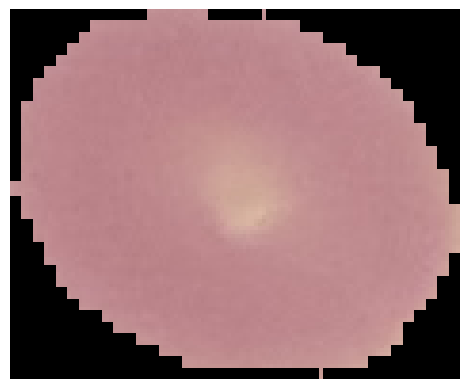

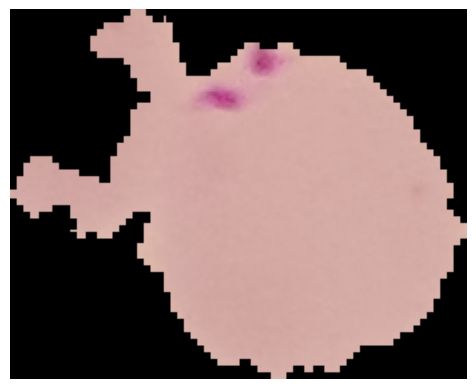

In [ ]:
def showImg(img_path): # a funtion to display imgs
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
showImg(uninfected_images[0])
showImg(parasitized_images[0])


# Preprocessing and Train/Test Split

In [9]:
# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 64

# TensorFlow equivalent of PyTorch transforms
# Rescaling the pixel values from [0, 255] to [-1, 1]
# The `CenterCrop` layer crops the image to the target size by removing pixels from the edges.
# The `Resizing` layer resizes images to a target size.

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_base_path,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.3, # 30% for validation and test combined
    subset='training'
)

val_test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_base_path,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.3, # 30% for validation and test combined
    subset='validation'
)

# Get class names before applying transformations
CLASS_NAMES = train_ds_raw.class_names

# Split the val_test_ds into validation and test sets
val_batches = tf.data.experimental.cardinality(val_test_ds_raw) // 2
val_ds_raw = val_test_ds_raw.take(val_batches)
test_ds_raw = val_test_ds_raw.skip(val_batches)

# Preprocessing layers for normalization
preprocess_input = tf.keras.Sequential([
    layers.Rescaling(1./127.5, offset=-1) # Scale pixels to [-1, 1]
])

# Apply preprocessing to all datasets
train_ds = train_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(lambda x, y: (preprocess_input(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)


print('Classes :', CLASS_NAMES)
print(f'Train Data samples : {tf.data.experimental.cardinality(train_ds) * BATCH_SIZE}')
print(f'Validation Data samples : {tf.data.experimental.cardinality(val_ds) * BATCH_SIZE}')
print(f'Test Data samples : {tf.data.experimental.cardinality(test_ds) * BATCH_SIZE}')

Found 27558 files belonging to 2 classes.
Using 19291 files for training.
Found 27558 files belonging to 2 classes.
Using 8267 files for validation.
Classes : ['Parasitized', 'Uninfected']
Train Data samples : 19328
Validation Data samples : 4160
Test Data samples : 4160


Batch images shape: (64, 224, 224, 3)
Batch labels shape: (64,)


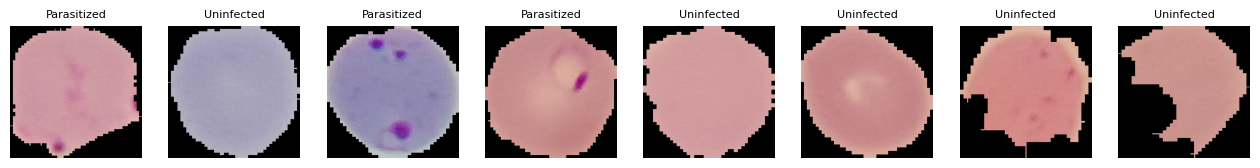

In [ ]:
# Take one batch from the training dataset
for batch_images, batch_labels in train_ds.take(1):
    pass

print('Batch images shape:', batch_images.shape)
print('Batch labels shape:', batch_labels.shape)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, img_tensor, lbl_tensor in zip(axes, batch_images[:8], batch_labels[:8]):
    # Convert tensor to numpy array
    img_np = img_tensor.numpy()

    # Unnormalize the images for display
    # Images were scaled to [-1, 1], so reverse this: (img * 0.5) + 0.5
    img_np = (img_np * 0.5) + 0.5
    img_np = np.clip(img_np, 0, 1) # Clip values to [0, 1]

    ax.imshow(img_np)
    ax.set_title(CLASS_NAMES[lbl_tensor.numpy()], fontsize=8) # Convert label tensor to numpy scalar
    ax.axis('off')
plt.show()

## Classical ML: HOG + SVM / Random Forest

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Function to extract HOG + Color Histogram features from a single image
def extract_features(img_path, img_size=(64, 64)):
    img = cv2.imread(img_path)
    img = cv2.resize(img, img_size)

    # 1. Color Histogram (HSV representation)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
    hist_feat = cv2.normalize(hist, hist).flatten()

    # 2. HOG Features (Grayscale)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=False)

    # Combine feature vectors
    return np.hstack([hog_feat, hist_feat])

In [12]:
# 1. Stratified Split (70% Train, 15% Val, 15% Test)
# Map labels: Parasitized -> 0, Uninfected -> 1
label_map = {'Parasitized': 0, 'Uninfected': 1}
df['label_idx'] = df['label'].map(label_map)

# Split Train (70%) and Temp (30%)
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    df['image_path'].values,
    df['label_idx'].values,
    test_size=0.30,
    random_state=42,
    stratify=df['label_idx'].values
)

# Split Temp into Val (15%) and Test (15%)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train samples: {len(X_train_paths)}")
print(f"Validation samples: {len(X_val_paths)}")
print(f"Test samples: {len(X_test_paths)}")

Train samples: 19290
Validation samples: 4134
Test samples: 4134


In [ ]:
# 2. Extract Features for Train, Val, and Test Sets
print("\nExtracting features for Training Set...")
X_train_feats = np.array([extract_features(p) for p in tqdm(X_train_paths)])

print("\nExtracting features for Validation Set...")
X_val_feats = np.array([extract_features(p) for p in tqdm(X_val_paths)])

print("\nExtracting features for Test Set...")
X_test_feats = np.array([extract_features(p) for p in tqdm(X_test_paths)])



Extracting features for Training Set...


100%|██████████| 19290/19290 [2:28:03<00:00,  2.17it/s]



Extracting features for Validation Set...


100%|██████████| 4134/4134 [31:28<00:00,  2.19it/s]



Extracting features for Test Set...


100%|██████████| 4134/4134 [32:36<00:00,  2.11it/s]


In [ ]:
# 3. Train & Evaluate Baseline Models
# A. Linear SVM Baseline
print("\n--- Training Linear SVM ---")
svm_model = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm_model.fit(X_train_feats, y_train)

y_pred_svm = svm_model.predict(X_test_feats)

print("\nLinear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Parasitized', 'Uninfected']))


--- Training Linear SVM ---

Linear SVM Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.85      0.83      0.84      2067
  Uninfected       0.83      0.85      0.84      2067

    accuracy                           0.84      4134
   macro avg       0.84      0.84      0.84      4134
weighted avg       0.84      0.84      0.84      4134



In [ ]:
# B. Random Forest Baseline
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_feats, y_train)

y_pred_rf = rf_model.predict(X_test_feats)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Parasitized', 'Uninfected']))


--- Training Random Forest ---

Random Forest Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.94      0.96      0.95      2067
  Uninfected       0.96      0.94      0.95      2067

    accuracy                           0.95      4134
   macro avg       0.95      0.95      0.95      4134
weighted avg       0.95      0.95      0.95      4134



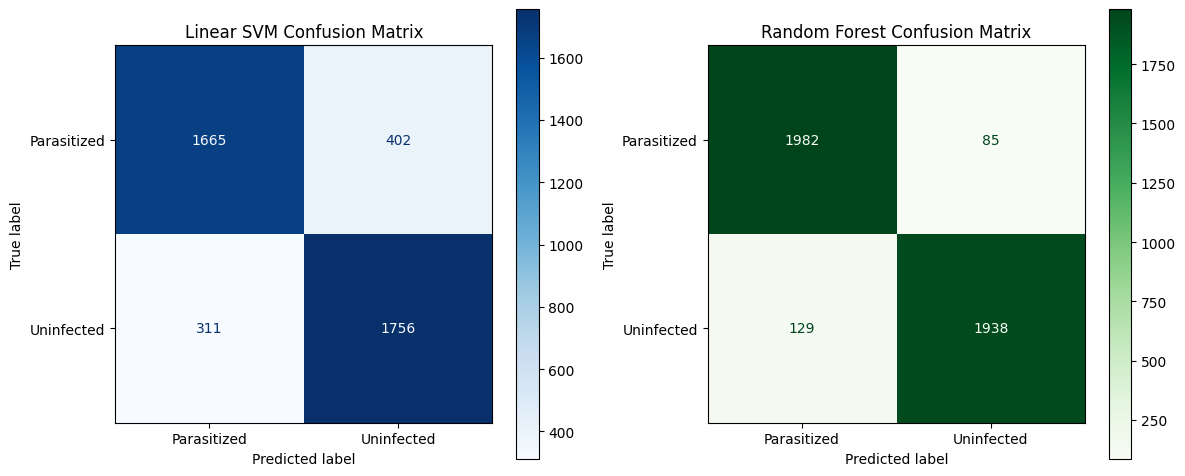

In [ ]:
# 4. Display Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=['Parasitized', 'Uninfected'],
    ax=axes[0], cmap='Blues'
)
axes[0].set_title('Linear SVM Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Parasitized', 'Uninfected'],
    ax=axes[1], cmap='Greens'
)
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

In [ ]:
# Predict probabilities for Random Forest
y_probs_rf = rf_model.predict_proba(X_test_feats)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs_rf)
pr_auc = average_precision_score(y_test, y_probs_rf)

print(f"Random Forest ROC-AUC Score: {roc_auc:.4f}")
print(f"Random Forest PR-AUC Score:  {pr_auc:.4f}")

Random Forest ROC-AUC Score: 0.9860
Random Forest PR-AUC Score:  0.9849


### Baseline Evaluation

- **Best Baseline Model:** Random Forest Classifier outclassed Linear SVM across all evaluation metrics.
- **Sensitivity/Recall Analysis:**
  - **Random Forest** achieved a remarkable Recall of **~95.89%** for the `Parasitized` class, misclassifying only 85 infected samples out of 2067.
  - **Linear SVM** achieved a lower Recall of **~80.55%**, leaving 402 infected cells undetected.
- **Conclusion & Limitations:** While non-linear Decision Trees with handcrafted HOG and Color features provided a strong baseline, they still rely heavily on manual feature engineering. These results set a solid performance benchmark for the Deep Learning models (Custom CNN & Transfer Learning) to beat in subsequent tasks.

## Custom CNN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# for loading the model if needed
from tensorflow import keras
model_cnn = keras.models.load_model("/content/drive/MyDrive/Malaria Cell Detection/best_cnn_model.keras")

In [ ]:
label_map = {'Parasitized': 0, 'Uninfected': 1}
df['label_idx'] = df['label'].map(label_map)

X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    df['image_path'].values,
    df['label_idx'].values,
    test_size=0.30,
    random_state=42,
    stratify=df['label_idx'].values
)

X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 64

CLASS_NAMES = ['Parasitized', 'Uninfected']

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH], method='nearest')
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0
    return img, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_cnn = make_dataset(X_train_paths, y_train, shuffle=True)
val_ds_cnn   = make_dataset(X_val_paths,   y_val,   shuffle=False)
test_ds_cnn  = make_dataset(X_test_paths,  y_test,  shuffle=False)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
])

In [ ]:
model_cnn = models.Sequential([
    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Conv2D(32,(3,3),padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256,(3,3),padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 406,849 (1.55 MB)

 Trainable params: 405,889 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_cnn_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
start_time = time.time()
history_cnn = model_cnn.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=30,
    callbacks=callbacks
)
cnn_training_time = time.time() - start_time
print(f"Training time: {cnn_training_time / 60:.2f} minutes")

Epoch 1/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7817 - loss: 0.4595 
Epoch 1: val_loss improved from None to 0.22823, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 5045s 17s/step - accuracy: 0.8724 - loss: 0.3140 - val_accuracy: 0.9376 - val_loss: 0.2282 - learning_rate: 5.0000e-04
Epoch 2/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9412 - loss: 0.1803
Epoch 2: val_loss improved from 0.22823 to 0.14858, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 86s 285ms/step - accuracy: 0.9437 - loss: 0.1761 - val_accuracy: 0.9507 - val_loss: 0.1486 - learning_rate: 5.0000e-04
Epoch 3/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9485 - loss: 0.1695
Epoch 3: val_loss did not improve from 0.14858
302/302 ━━━━━━━━━━━━━━━━━━━━ 144s 290ms/step - accuracy: 0.9492 - loss: 0.1628 - val_accuracy: 0.9516 - val

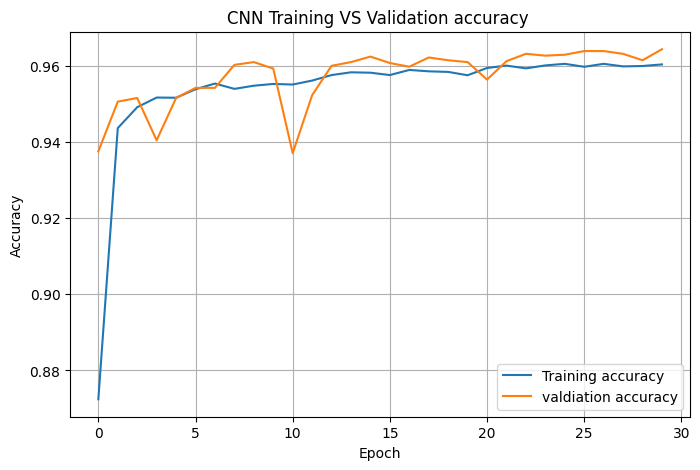

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    history_cnn.history["accuracy"],
    label="Training accuracy"
)
plt.plot(
    history_cnn.history["val_accuracy"],
    label="valdiation accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training VS Validation accuracy ")
plt.legend()
plt.grid(True)


plt.show()

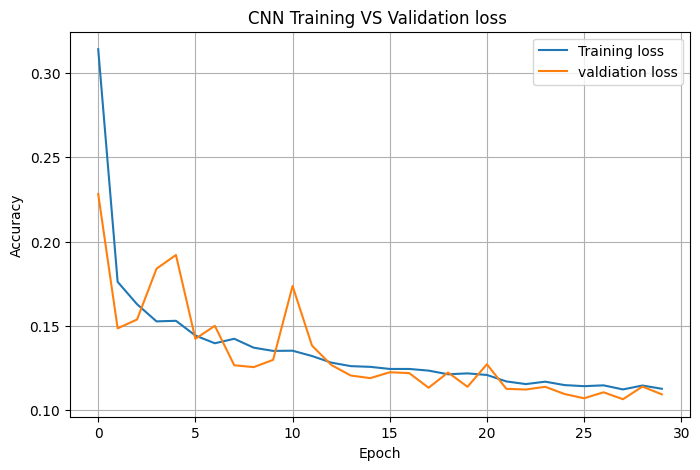

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    history_cnn.history["loss"],
    label="Training loss"
)
plt.plot(
    history_cnn.history["val_loss"],
    label="valdiation loss"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training VS Validation loss ")
plt.legend()
plt.grid(True)


plt.show()

In [ ]:
test_loss, test_accuracy = (
    model_cnn.evaluate(test_ds_cnn)
)
print(f"Test Accuracy:  {test_accuracy:.4f}")


65/65 ━━━━━━━━━━━━━━━━━━━━ 1225s 19s/step - accuracy: 0.9632 - loss: 0.1108
Test Accuracy:  0.9632


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_true_cnn = []
y_pred_cnn = []
y_scores_cnn = []

for images, labels in test_ds:
    predictions = model_cnn.predict(images, verbose=0)
    y_true_cnn.extend(labels.numpy())
    y_pred_cnn.extend((predictions >= 0.5).astype(int).flatten())
    y_scores_cnn.extend(predictions.flatten())

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)
y_scores_cnn = np.array(y_scores_cnn)

roc_auc_cnn = roc_auc_score(y_true_cnn, y_scores_cnn)
pr_auc_cnn = average_precision_score(y_true_cnn, y_scores_cnn)
print(f"ROC-AUC: {roc_auc_cnn:.4f}")
print(f"PR-AUC:  {pr_auc_cnn:.4f}")

ROC-AUC: 0.9933
PR-AUC:  0.9933


In [ ]:
# exploring the precision/recall trade-off for the infected class
print("Threshold tuning — impact on Parasitized (infected) class recall\n")

for t in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred_t_cnn = (y_scores_cnn >= t).astype(int)
    print(f" Threshold = {t} ")
    print(classification_report(y_true_cnn, y_pred_t_cnn, target_names=CLASS_NAMES, zero_division=0))
    print()

Threshold tuning — impact on Parasitized (infected) class recall

 Threshold = 0.5 
              precision    recall  f1-score   support

 Parasitized       0.97      0.96      0.96      2030
  Uninfected       0.96      0.97      0.96      2077

    accuracy                           0.96      4107
   macro avg       0.96      0.96      0.96      4107
weighted avg       0.96      0.96      0.96      4107


 Threshold = 0.45 
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2030
  Uninfected       0.95      0.97      0.96      2077

    accuracy                           0.96      4107
   macro avg       0.96      0.96      0.96      4107
weighted avg       0.96      0.96      0.96      4107


 Threshold = 0.4 
              precision    recall  f1-score   support

 Parasitized       0.98      0.95      0.96      2030
  Uninfected       0.95      0.98      0.96      2077

    accuracy                           0.96      4107
   ma

In [ ]:
cm_cnn =confusion_matrix(y_true_cnn, y_pred_cnn)
CR_cnn = classification_report(
    y_true_cnn,
    y_pred_cnn,
    target_names= CLASS_NAMES

)
print(cm_cnn)
print(CR_cnn)

[[1945   85]
 [  69 2008]]
              precision    recall  f1-score   support

 Parasitized       0.97      0.96      0.96      2030
  Uninfected       0.96      0.97      0.96      2077

    accuracy                           0.96      4107
   macro avg       0.96      0.96      0.96      4107
weighted avg       0.96      0.96      0.96      4107



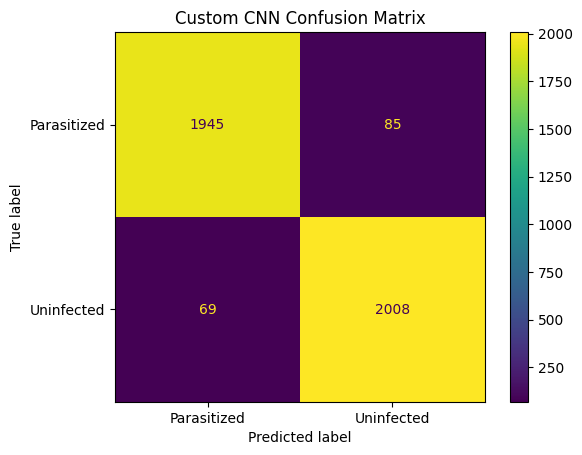

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=CLASS_NAMES
).plot()

plt.title("Custom CNN Confusion Matrix")
plt.show()

* validation loss improved steadily.
* no overfitting happened, validation loss end up slightly below training loss in epoch 25+ -agumentation is likely preventing the model from memorizing the data .
* early stopping was never triggered , since the val_loss kept finding a new best before the patience reaches 6 .
* in the test the model reached **96% accuracy**  with **ROC-AUC = 0.9933** and **PR-AUC = 0.9933**, indecating seprability between infected and uninfected cells.
* the confusion matrix shows the balanced performance accross both classes ,with precision and recall both around 0.96–0.97 for Parasitized and Uninfected.
* threshold tuning showed the default 0.5 already gives the best overall balanced .
* data agumentation contributed to this generelization , since the model reached high test performance without needing to memorize training images .

## Transfer Learning

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
NUM_CLASSES = 2 # Configurable variable
DATA_DIR = '/content/malaria_data/cell_images/cell_images'

# Load the dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Create the Transfer Learning Model
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model weights

model = models.Sequential([
    # Data Preprocessing/Normalization for MobileNetV2 (scales [0, 255] to [-1, 1])
    layers.Input(shape=IMG_SIZE + (3,)),
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 10 epochs (Feature Extraction)
print("Starting Feature Extraction Phase...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

#  Fine-Tuning Phase (Optional)
print("\nStarting Fine-Tuning Phase...")
base_model.trainable = True

# Unfreeze only the last few layers (e.g., from layer 100 onwards)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 5 more epochs
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

print("Transfer Learning Complete.")

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Starting Feature Extraction Phase...
Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 80s 174ms/step - accuracy: 0.8976 - loss: 0.2534 - val_accuracy: 0.9388 - val_loss: 0.1713
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.9328 - loss: 0.1873 - val_accuracy: 0.9410 - val_loss: 0.1620
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.9361 - loss: 0.1787 - val_accuracy: 0.9448 - val_loss: 0.1565
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.9388 - loss: 0.1742 - val_accuracy: 0.9452 - val_loss: 0.1527
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.9387 - loss: 0.1726 - val_accuracy: 0.9441 - val_loss: 0.1541
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.9419 - loss: 0.1644 - val_accuracy: 0.9452 - v

In [ ]:
model.save("/content/drive/MyDrive/Malaria Cell Detection/malaria_mobilenetv2_v1.keras")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from tensorflow.keras.models import load_model

# Load Custom CNN Model
model_path = "/content/drive/MyDrive/Malaria Cell Detection/best_cnn_model.keras"
print(f"Loading Custom CNN Model from: {model_path}...")
model_cnn = load_model(model_path)
print("Model loaded successfully!")

#  Predictions for Custom CNN
print("Predicting with Custom CNN...")
cnn_probs = model_cnn.predict(test_ds).flatten()
cnn_preds = (cnn_probs > 0.5).astype(int)

#  Predictions for MobileNetV2
print("Predicting with MobileNetV2...")
y_val_list = []
tl_probs_list = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    tl_probs_list.extend(preds[:, 1])
    y_val_list.extend(labels.numpy())

y_val_tl = np.array(y_val_list)
tl_probs = np.array(tl_probs_list)
tl_preds = (tl_probs > 0.5).astype(int)

#  Compile Performance Comparison Table
results = pd.DataFrame(
    {
        "Model": ["Linear SVM", "Random Forest", "Custom CNN", "MobileNetV2 (Transfer Learning)"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_svm),
            accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_test, cnn_preds),
            accuracy_score(y_val_tl, tl_preds),
        ],
        "Precision": [
            precision_score(y_test, y_pred_svm),
            precision_score(y_test, y_pred_rf),
            precision_score(y_test, cnn_preds),
            precision_score(y_val_tl, tl_preds),
        ],
        "Recall": [
            recall_score(y_test, y_pred_svm),
            recall_score(y_test, y_pred_rf),
            recall_score(y_test, cnn_preds),
            recall_score(y_val_tl, tl_preds),
        ],
        "F1-Score": [
            f1_score(y_test, y_pred_svm),
            f1_score(y_test, y_pred_rf),
            f1_score(y_test, cnn_preds),
            f1_score(y_val_tl, tl_preds),
        ],
        "ROC-AUC": [
            None,
            roc_auc_score(y_test, y_probs_rf),
            roc_auc_score(y_test, cnn_probs),
            roc_auc_score(y_val_tl, tl_probs),
        ],
    }
)

#  Sort Table by F1-Score
results = results.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print(" Model Performance Comparison ")
display(results)

# Print Best Model
best_model_idx = results["F1-Score"].idxmax()
best_model_name = results.loc[best_model_idx, "Model"]
best_model_score = results.loc[best_model_idx, "F1-Score"]

print(
    f" The Best Model is: {best_model_name} with an F1-Score of {best_model_score:.4f}"
)

<>:86: SyntaxWarning: invalid escape sequence '\ '
<>:86: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4400/3642293503.py:86: SyntaxWarning: invalid escape sequence '\ '
  f"\ The Best Model is: {best_model_name} with an F1-Score of {best_model_score:.4f}"


Loading Custom CNN Model from: /content/drive/MyDrive/Malaria Cell Detection/best_cnn_model.keras...
Model loaded successfully!
Predicting with Custom CNN...
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step
Predicting with MobileNetV2...

 Model Performance Comparison 


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,MobileNetV2 (Transfer Learning),0.954818,0.932377,0.981661,0.956385,0.989637
1,Random Forest,0.948234,0.957983,0.937591,0.947677,0.985979
2,Linear SVM,0.827528,0.813716,0.849540,0.831243,NaN
3,Custom CNN,0.695452,0.742497,0.598452,0.662738,0.758304


\ The Best Model is: MobileNetV2 (Transfer Learning) with an F1-Score of 0.9564


In [ ]:
print("Feature Extraction History:")
print("Best Validation Accuracy:",
      max(history.history["val_accuracy"]))

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("\nFine-Tuning History:")
print("Best Validation Accuracy:",
      max(history_fine.history["val_accuracy"]))

print("Final Validation Accuracy:",
      history_fine.history["val_accuracy"][-1])

Feature Extraction History:
Best Validation Accuracy: 0.9466521739959717
Final Validation Accuracy: 0.940301239490509

Fine-Tuning History:
Best Validation Accuracy: 0.951732873916626
Final Validation Accuracy: 0.951732873916626


In [ ]:
# Evaluate MobileNetV2 on the validation set

results = model.evaluate(val_ds, verbose=1)

print("\nMobileNetV2 Evaluation Results:")
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]:.4f}")

87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.9517 - loss: 0.1618

MobileNetV2 Evaluation Results:
Loss: 0.1618
Accuracy: 0.9517


## Grad-CAM (explainability)

Testing Grad-CAM on the deployed model (`MobileNetV2`, the best-performing one, F1 = 0.9564).
Uses the already-trained `model` variable in memory from the training cell above — if you're
running this in a fresh session, it reloads from the saved `.keras` file instead.

In [14]:
import cv2
import numpy as np
import tensorflow as tf

BASE_MODEL_NAME = "mobilenetv2_1.00_224"
LAST_CONV_LAYER_NAME = "out_relu"  # last activated feature map before pooling, (7,7,1280)


def make_gradcam_heatmap(img_array, model, pred_index=None):

    base_model = model.get_layer(BASE_MODEL_NAME)

    # Find where MobileNetV2 is inside the Sequential model
    base_idx = model.layers.index(base_model)

    with tf.GradientTape() as tape:

        # Start with the same input that goes into the model
        x = img_array

        # Apply layers before MobileNetV2
        for layer in model.layers[:base_idx]:

            if isinstance(layer, tf.keras.layers.InputLayer):
                continue

            x = layer(x)

        # MobileNetV2 output = last feature map
        # Shape should be approximately (batch, 7, 7, 1280)
        conv_output = base_model(x, training=False)

        tape.watch(conv_output)

        # Pass feature map through the classification head
        y = conv_output

        for layer in model.layers[base_idx + 1:]:

            if isinstance(layer, tf.keras.layers.Dropout):
                y = layer(y, training=False)
            else:
                y = layer(y)

        predictions = y

        # If no class is provided, explain predicted class
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Gradients of predicted class with respect to feature map
    grads = tape.gradient(class_channel, conv_output)

    if grads is None:
        raise RuntimeError(
            "Grad-CAM failed: gradients are None."
        )

    # Average gradients over spatial dimensions
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_output = conv_output[0]

    # Weighted combination of feature maps
    heatmap = tf.reduce_sum(
        conv_output * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_val = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_val > 0,
        heatmap / max_val,
        tf.zeros_like(heatmap)
    )

    return heatmap.numpy()

In [15]:
def overlay_heatmap(heatmap, original_rgb, alpha=0.4):

    heatmap_resized = cv2.resize(
        heatmap,
        (original_rgb.shape[1], original_rgb.shape[0])
    )

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_colored = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_colored = cv2.cvtColor(
        heatmap_colored,
        cv2.COLOR_BGR2RGB
    )

    overlay = (
        heatmap_colored * alpha
        + original_rgb * (1 - alpha)
    )

    return np.uint8(overlay)

Using `model` already in memory.
Last 5 layers of the base model:
  block_16_project (None, 7, 7, 320)
  block_16_project_BN (None, 7, 7, 320)
  Conv_1 (None, 7, 7, 1280)
  Conv_1_bn (None, 7, 7, 1280)
  out_relu (None, 7, 7, 1280)

Found 13779 Parasitized images

Prediction: Parasitized (96.66% confidence)


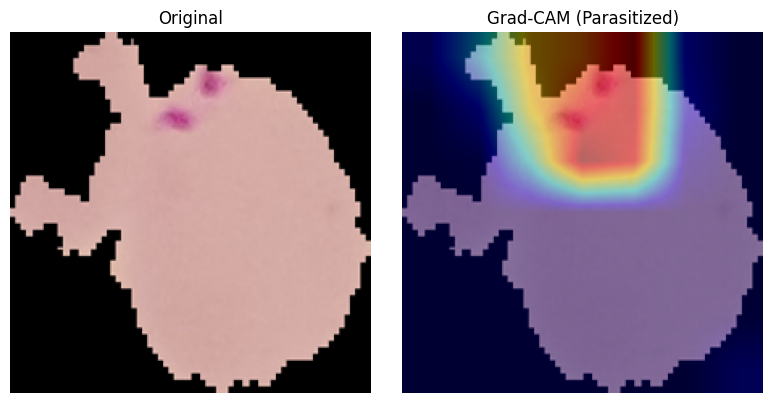

In [16]:
import glob
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# Load the trained model from disk if `model` isn't already in memory
# (e.g. if you're running this cell in a fresh Colab session)
try:
    model
    print("Using `model` already in memory.")
except NameError:
    model_path = f"{project_folder}/malaria_mobilenetv2_v1.keras"
    print(f"Loading model from: {model_path}")
    model = tf.keras.models.load_model(model_path)

# Sanity check: confirm the expected layer names exist
base_model_check = model.get_layer(BASE_MODEL_NAME)
print("Last 5 layers of the base model:")
for layer in base_model_check.layers[-5:]:
    try:
        shape = layer.output.shape
    except AttributeError:
        shape = "(not built yet)"
    print(" ", layer.name, shape)
# Grab a real sample image from your Data folder
sample_paths = glob.glob(f"{project_folder}/Data/Parasitized/*.png")
print(f"\nFound {len(sample_paths)} Parasitized images")

img_path = sample_paths[0]
img = Image.open(img_path).convert("RGB").resize((224, 224))
img_array = np.expand_dims(
    np.array(img, dtype=np.float32),
    axis=0
)

# Run the actual prediction so the heatmap explains the real predicted class
probs = model.predict(img_array, verbose=0)[0]
pred_idx = int(np.argmax(probs))
pred_label = CLASS_NAMES[pred_idx]
print(f"\nPrediction: {pred_label} ({probs[pred_idx]*100:.2f}% confidence)")

heatmap = make_gradcam_heatmap(img_array, model, pred_index=pred_idx)
overlay = overlay_heatmap(heatmap, np.array(img))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(overlay); axes[1].set_title(f"Grad-CAM ({pred_label})"); axes[1].axis("off")
plt.tight_layout()
plt.show()

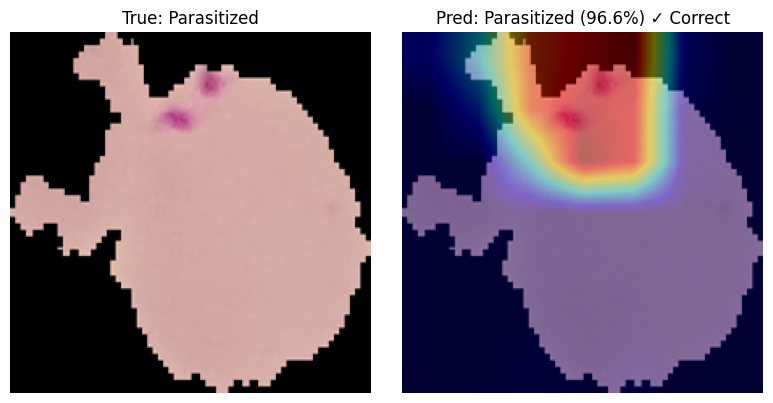

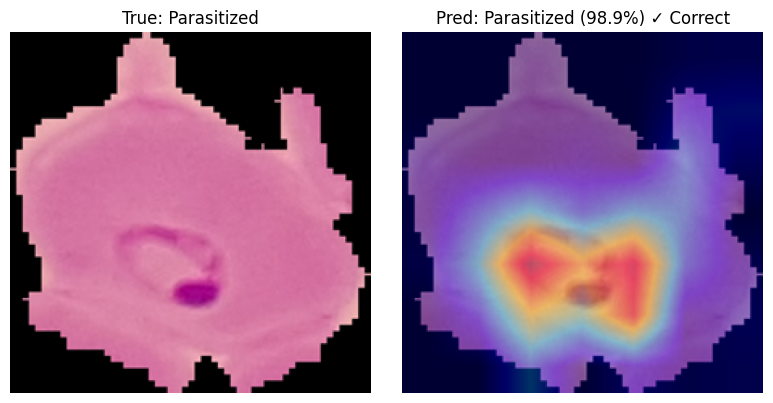

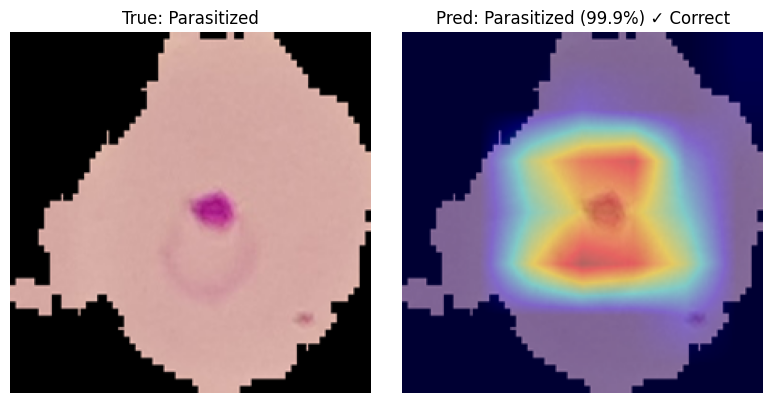

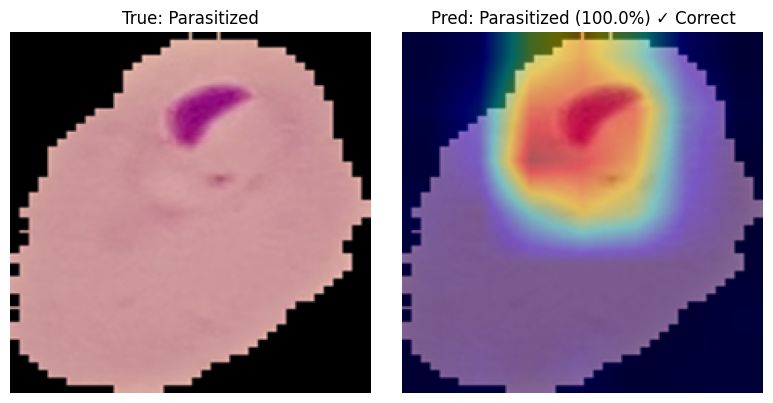

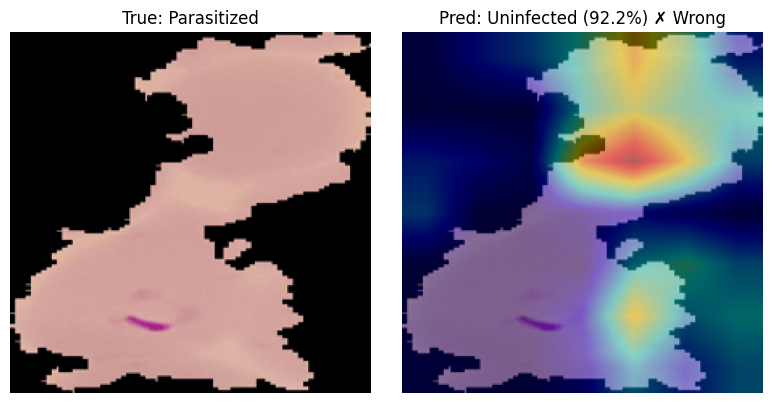

In [ ]:
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def predict_and_explain(img_path, true_label):

    img = Image.open(img_path).convert("RGB").resize((224, 224))

    # Raw image: preprocessing is already inside the model
    img_array = np.expand_dims(
        np.array(img, dtype=np.float32),
        axis=0
    )

    probs = model.predict(img_array, verbose=0)[0]

    pred_idx = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]

    correct = (pred_label == true_label)

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        pred_index=pred_idx
    )

    overlay = overlay_heatmap(
        heatmap,
        np.array(img)
    )

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img)
    axes[0].set_title(f"True: {true_label}")
    axes[0].axis("off")

    status = "✓ Correct" if correct else "✗ Wrong"

    axes[1].imshow(overlay)
    axes[1].set_title(
        f"Pred: {pred_label} "
        f"({probs[pred_idx]*100:.1f}%) {status}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    return correct


parasitized_paths = glob.glob(
    f"{project_folder}/Data/Parasitized/*.png"
)

for p in parasitized_paths[:5]:
    predict_and_explain(p, "Parasitized")

## Streamlit app

In [1]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 39.4 MB/s eta 0:00:00


In [17]:
project_folder = '/content/drive/MyDrive/Malaria Cell Detection'
!unzip -o "{project_folder}/malaria-mlops.zip" -d "{project_folder}"
%cd "{project_folder}/malaria-mlops"

import shutil, os
os.makedirs("models", exist_ok=True)
shutil.copy(f"{project_folder}/malaria_mobilenetv2_v1.keras",
            "models/malaria_mobilenetv2_v1.keras")

Archive:  /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops.zip
   creating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/
  inflating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/requirements.txt  
   creating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/app/
  inflating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/app/gradcam.py  
  inflating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/app/app.py  
  inflating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/README.md  
  inflating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/Dockerfile  
   creating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/logs/
   creating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/models/
  inflating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/models/README.md  
  inflating: /content/drive/MyDrive/Malaria Cell Detection/malaria-mlops/models/mod

'models/malaria_mobilenetv2_v1.keras'

In [18]:
from pyngrok import ngrok
import subprocess, time

ngrok.set_auth_token("3JLnQ1odkyVkt7UW7FhbgYmAlqC_2M9RG1tvPipq6NWpd6NUx")

subprocess.Popen(["streamlit", "run", "app/app.py",
                   "--server.port=8501", "--server.headless=true"])
time.sleep(5)

public_url = ngrok.connect(8501)
print("Open this link:", public_url)

Open this link: NgrokTunnel: "https://omen-faucet-childcare.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
ngrok.kill()
print("All ngrok tunnels closed.")

All ngrok tunnels closed.


## Tests

In [ ]:
%cd "{project_folder}/malaria-mlops"
!pytest tests/ -v

/content/drive/.shortcut-targets-by-id/176kI2AlE0PtjK7MsGYYtXXucNNdLOKlT/Malaria Cell Detection/malaria-mlops
============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/drive/.shortcut-targets-by-id/176kI2AlE0PtjK7MsGYYtXXucNNdLOKlT/Malaria Cell Detection/malaria-mlops
plugins: anyio-4.14.2, langsmith-0.12.1, typeguard-4.6.0
collected 6 items                                                              

tests/test_app.py::test_preprocess_image_shape PASSED                    [ 16%]
tests/test_app.py::test_preprocess_image_value_range PASSED              [ 33%]
tests/test_app.py::test_class_names_defined PASSED                       [ 50%]
tests/test_app.py::test_log_prediction_writes_row PASSED                 [ 66%]
tests/test_app.py::test_log_prediction_appends PASSED                    [ 83%]
tests/test_app.py::test_overlay_heatmap_shape_a

In [ ]:
import pandas as pd
pd.read_csv("logs/predictions_log.csv")

,timestamp,filename,prediction,confidence,model_version
0,2026-09-15T14:47:00.716660,C37BP2_thinF_IMG_20150620_133111a_cell_87.png,Uninfected,0.9597,v1
1,2026-09-15T14:49:11.929085,C1_thinF_IMG_20150604_104722_cell_15.png,Uninfected,0.9738,v1
2,2026-09-15T14:49:24.886802,C33P1thinF_IMG_20150619_114756a_cell_180.png,Uninfected,0.9437,v1
